# 05 — Soil

Auto-downloads SSURGO soil polygons from USDA Soil Data Access (SDA), clips to the vineyard, and computes area-weighted soil property summaries per subplot.

No manual downloads required — intermediate files are cached locally on first run.

In [1]:
import os, io, requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

SOIL_DIR = '../data/soil'
IMG_DIR  = '../img'
os.makedirs(SOIL_DIR, exist_ok=True)
os.makedirs(IMG_DIR,  exist_ok=True)

SDA_URL = 'https://SDMDataAccess.sc.egov.usda.gov/Tabular/post.rest'

def sda_query(sql, columns):
    resp = requests.post(SDA_URL, data={'query': sql, 'format': 'JSON'}, timeout=120)
    resp.raise_for_status()
    result = resp.json()
    if 'Table' not in result or result['Table'] is None:
        raise ValueError('SDA returned no data for query.')
    return pd.DataFrame(result['Table'], columns=columns)


/home/simonhans/anaconda3/envs/GrapeExpectations/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


In [11]:
vineyard = gpd.read_file('../data/polygons/RegressionRidge_smol_smol.geojson').to_crs('EPSG:4326')
plots    = gpd.read_file('../data/polygons/RegressionRidge.geojson').to_crs('EPSG:4326')
plots    = plots.reset_index(drop=True)
plots['plot_id'] = plots.index

print('Vineyard bounds:', vineyard.total_bounds)
print('Subplots:', len(plots))

DriverError: ../data/polygons/RegressionRidge_smol_smol.geojson: No such file or directory

In [5]:
# ── Soil polygons from SDA WFS (cached after first run) ──────────────────────
poly_path = SOIL_DIR + '/soil_polys.gpkg'

if os.path.exists(poly_path):
    print('Loading cached soil polygons...')
    soils = gpd.read_file(poly_path)
else:
    print('Downloading soil polygons from SSURGO SDA...')
    bounds = vineyard.total_bounds   # [minx, miny, maxx, maxy]
    bbox   = '{},{},{},{}'.format(*bounds)

    wfs_url = (
        'https://SDMDataAccess.sc.egov.usda.gov/Spatial/SDMWGS84Geographic.wfs'
        '?Service=WFS&Version=1.0.0&Request=GetFeature'
        '&TypeName=MapunitPolyExtended&BBOX=' + bbox
    )
    resp = requests.get(wfs_url, timeout=180)
    resp.raise_for_status()

    soils = gpd.read_file(io.BytesIO(resp.content))
    soils.columns = soils.columns.str.lower()
    soils = soils.set_crs('EPSG:4326')   # WFS is already WGS84; just label it
    soils = gpd.clip(soils, vineyard)
    soils.to_file(poly_path, driver='GPKG')
    print('  Saved to', poly_path)

print('Map units:', soils['mukey'].nunique())
soils[['mukey', 'musym', 'muname']].drop_duplicates().reset_index(drop=True)

  Saved to ../data/soil/soil_polys.gpkg
Map units: 4


,mukey,musym,muname
0,69510,BdE,"Burbank loamy fine sand, basalt substratum, 0 ..."
1,69569,QuE,"Quincy loamy sand, 0 to 30 percent"
2,69511,BfE,"Burbank rocky loamy fine sand, basalt substrat..."
3,69570,QyE,"Quincy loamy sand, moderately shallow, 0 to 30..."


In [6]:
# ── Tabular data from SDA: components, horizons, restrictions ─────────────────
mukeys     = soils['mukey'].unique().tolist()
mukey_list = ','.join("'" + k + "'" for k in mukeys)

# Major components only
print('Fetching components...')
components = sda_query(
    'SELECT mukey, cokey, compname, comppct_r, drainagecl '
    'FROM component '
    'WHERE mukey IN (' + mukey_list + ') '
    "AND majcompflag = 'Yes'",
    columns=['mukey', 'cokey', 'compname', 'comppct_r', 'drainagecl']
)
components['comppct_r'] = pd.to_numeric(components['comppct_r'])

cokey_list = ','.join("'" + k + "'" for k in components['cokey'].unique())

# Soil horizons
print('Fetching horizons...')
horizons = sda_query(
    'SELECT cokey, hzname, hzdept_r, hzdepb_r, '
    'sandtotal_r, silttotal_r, claytotal_r, '
    'ph1to1h2o_r, cec7_r, om_r, awc_r, ec_r, '
    'dbovendry_r, kffact, kwfact, caco3_r, '
    'frag3to10_r, fraggt10_r, '
    'wthirdbar_r, wtenthbar_r, wfifteenbar_r, wsatiated_r '
    'FROM chorizon '
    'WHERE cokey IN (' + cokey_list + ')',
    columns=['cokey', 'hzname', 'hzdept_r', 'hzdepb_r',
             'sandtotal_r', 'silttotal_r', 'claytotal_r',
             'ph1to1h2o_r', 'cec7_r', 'om_r', 'awc_r', 'ec_r',
             'dbovendry_r', 'kffact', 'kwfact', 'caco3_r',
             'frag3to10_r', 'fraggt10_r',
             'wthirdbar_r', 'wtenthbar_r', 'wfifteenbar_r', 'wsatiated_r']
)

# Shallowest restriction per component
print('Fetching restriction depths...')
restrictions = sda_query(
    'SELECT cokey, MIN(resdept_r) AS restrictiondepth_cm '
    'FROM corestrictions '
    'WHERE cokey IN (' + cokey_list + ') '
    'GROUP BY cokey',
    columns=['cokey', 'restrictiondepth_cm']
)
components = components.merge(restrictions, on='cokey', how='left')
components['restrictiondepth_cm'] = pd.to_numeric(components['restrictiondepth_cm'], errors='coerce')

NUMERIC_COLS = [
    'hzdept_r', 'hzdepb_r',
    'sandtotal_r', 'silttotal_r', 'claytotal_r',
    'ph1to1h2o_r', 'cec7_r', 'om_r', 'awc_r', 'ec_r',
    'dbovendry_r', 'kffact', 'kwfact', 'caco3_r',
    'frag3to10_r', 'fraggt10_r',
    'wthirdbar_r', 'wtenthbar_r', 'wfifteenbar_r', 'wsatiated_r',
]
for col in NUMERIC_COLS:
    if col in horizons.columns:
        horizons[col] = pd.to_numeric(horizons[col], errors='coerce')

print('Components:', len(components), ' | Horizons:', len(horizons))
components

Fetching components...
Fetching horizons...
Fetching restriction depths...
Components: 5  | Horizons: 13


,mukey,cokey,compname,comppct_r,drainagecl,restrictiondepth_cm
0,69510,26545354,Burbank,100,Excessively drained,64.0
1,69511,26545355,Burbank,50,Excessively drained,64.0
2,69511,26545356,Rock outcrop,35,None,0.0
3,69569,26545417,Quincy,90,Excessively drained,NaN
4,69570,26545418,Quincy,100,Excessively drained,76.0


In [7]:
# ── Summarize soil properties per MUKEY ──────────────────────────────────────
DRAIN_ORDER = {
    'Excessively drained': 1, 'Somewhat excessively drained': 2,
    'Well drained': 3, 'Moderately well drained': 4,
    'Somewhat poorly drained': 5, 'Poorly drained': 6, 'Very poorly drained': 7,
}

SOIL_COLS = [
    'sandtotal_r', 'silttotal_r', 'claytotal_r',
    'ph1to1h2o_r', 'cec7_r', 'om_r', 'awc_r', 'ec_r',
    'dbovendry_r', 'kffact', 'kwfact', 'caco3_r',
    'frag3to10_r', 'fraggt10_r',
    'wthirdbar_r', 'wtenthbar_r', 'wfifteenbar_r', 'wsatiated_r',
]

def wavg(values, weights):
    mask = values.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    return np.average(values[mask], weights=weights[mask])

def summarize(g, weight_col, extra_cols=None):
    out = {col: wavg(g[col], g[weight_col]) for col in SOIL_COLS if col in g.columns}
    if extra_cols:
        out.update({col: wavg(g[col], g[weight_col]) for col in extra_cols if col in g.columns})
    return pd.Series(out)

# Step 1: thickness-weighted average per component
hz = horizons.copy()
hz['thickness'] = hz['hzdepb_r'] - hz['hzdept_r']

comp_hz = (
    hz.groupby('cokey')
      .apply(lambda g: summarize(g, 'thickness').append(pd.Series({
          'profile_depth': g['hzdepb_r'].max() - g['hzdept_r'].min(),
          'max_depth':     g['hzdepb_r'].max(),
      })))
      .reset_index()
)

# Step 2: join component metadata
comp_hz = comp_hz.merge(
    components[['cokey', 'mukey', 'comppct_r', 'drainagecl', 'restrictiondepth_cm']],
    on='cokey'
)
comp_hz['drain_ord'] = comp_hz['drainagecl'].map(DRAIN_ORDER)

# Step 3: comppct-weighted average per MUKEY
SUMMARY_COLS = SOIL_COLS + ['profile_depth', 'max_depth', 'drain_ord', 'restrictiondepth_cm']
mu_summary = (
    comp_hz.groupby('mukey')
           .apply(lambda g: summarize(g, 'comppct_r', extra_cols=['profile_depth', 'max_depth', 'drain_ord', 'restrictiondepth_cm']))
           .reset_index()
)

mu_summary

,mukey,sandtotal_r,silttotal_r,claytotal_r,ph1to1h2o_r,cec7_r,om_r,awc_r,ec_r,dbovendry_r,...,frag3to10_r,fraggt10_r,wthirdbar_r,wtenthbar_r,wfifteenbar_r,wsatiated_r,profile_depth,max_depth,drain_ord,restrictiondepth_cm
0,69510,81.037500,16.462500,2.500000,7.0,3.500000,0.328125,0.071719,0.000000,1.552031,...,2.625,0.984375,7.171875,11.750000,1.514063,29.875000,74.000000,74.000000,1.0,64.000000
1,69511,81.037500,16.462500,2.500000,7.0,3.500000,0.328125,0.071719,0.000000,1.552031,...,2.625,0.984375,7.171875,11.750000,1.514063,29.875000,106.117647,106.117647,1.0,37.647059
2,69569,79.551316,16.524342,3.924342,7.9,3.651316,0.325658,0.101513,0.848684,1.662434,...,0.000,0.000000,11.390789,17.290789,3.045395,37.302632,152.000000,152.000000,1.0,NaN
3,69570,80.700000,16.800000,2.500000,7.9,2.500000,0.400000,0.090000,0.000000,1.620000,...,0.000,0.000000,9.700000,15.500000,2.100000,38.000000,86.000000,86.000000,1.0,76.000000


In [8]:
# ── Area-weighted soil summary per subplot ────────────────────────────────────
target_crs = 'EPSG:5070'   # Albers Equal Area — required for correct area weighting

plots_proj = plots[['plot_id', 'geometry']].to_crs(target_crs)
soils_proj = soils[['mukey', 'geometry']].to_crs(target_crs)

overlaps = gpd.overlay(plots_proj, soils_proj, how='intersection')
overlaps['area'] = overlaps.geometry.area
overlaps = overlaps.merge(mu_summary, on='mukey', how='left')

SUMMARY_COLS = SOIL_COLS + ['profile_depth', 'max_depth', 'drain_ord', 'restrictiondepth_cm']

plot_soil = (
    overlaps.groupby('plot_id')
            .apply(lambda g: pd.Series(dict(
                {col: wavg(g[col], g['area']) for col in SUMMARY_COLS if col in g.columns},
                **{'dominant_mukey': g.loc[g['area'].idxmax(), 'mukey']}
            )))
            .reset_index()
)

print('Plot soil summaries:', len(plot_soil), 'plots')
plot_soil[['plot_id', 'sandtotal_r', 'claytotal_r', 'ph1to1h2o_r', 'om_r', 'dominant_mukey']].head(10)

Plot soil summaries: 1 plots


,plot_id,sandtotal_r,claytotal_r,ph1to1h2o_r,om_r,dominant_mukey
0,0,80.224946,3.196042,7.669919,0.345296,69569


In [9]:
plot_soil.to_pickle(SOIL_DIR + '/plot_summary.pkl')
print('Saved to', SOIL_DIR + '/plot_summary.pkl')

Saved to ../data/soil/plot_summary.pkl


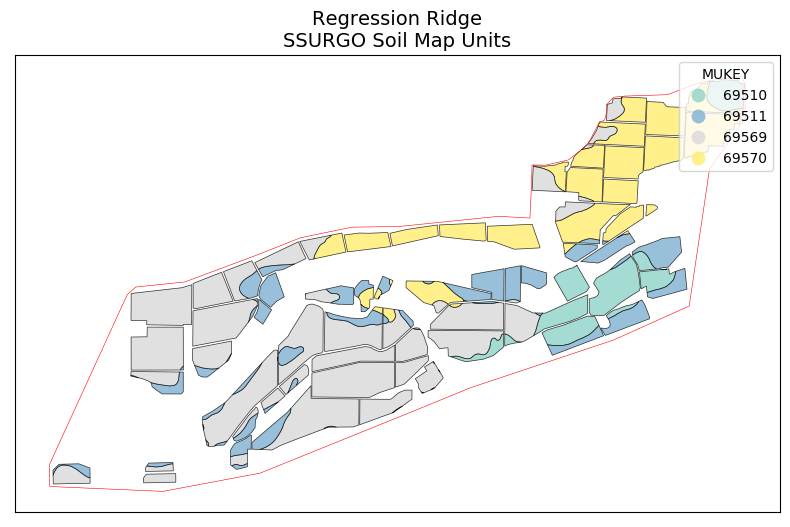

In [10]:
fig, ax = plt.subplots(figsize=(8, 7))

soils.to_crs('EPSG:32611').plot(
    ax=ax, column='mukey', cmap='Set3',
    edgecolor='black', linewidth=0.5, alpha=0.8,
    legend=True, legend_kwds={'title': 'MUKEY', 'fontsize': 10}
)
plots.to_crs('EPSG:32611').plot(
    ax=ax, facecolor='none', edgecolor='red', linewidth=0.4
)
ax.set_aspect('equal')
ax.set_xticks([]); ax.set_yticks([])
plt.title('Regression Ridge\nSSURGO Soil Map Units', fontsize=14)
plt.tight_layout()
plt.savefig(IMG_DIR + '/soil_map.png', dpi=150)
plt.show()